# 01 - Dataset Inspection

This analysis inspects the raw NASA Battery Aging files and builds an initial understanding of the signals that will later be used for RUL prediction.

The main focus is the discharge operation because it contains the measured capacity, which is the clearest health indicator for defining end of life and remaining useful life.


In [1]:
# Load utilities, scientific packages, plotting, and MATLAB file support.
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio

# Use readable plot defaults and make long table cells easier to inspect.
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)


## Raw Data

Get all available MATLAB files in the dataset folder.


In [2]:
# Locate the raw dataset and list available data/documentation files.
DATA_ROOT = Path(os.environ.get("NASA_BATTERY_DATA", "/home/aymen/data/nasa-battery"))

if not DATA_ROOT.exists():
    raise FileNotFoundError(f"Raw dataset folder not found: {DATA_ROOT}")

mat_files = sorted(DATA_ROOT.glob("**/B*.mat"))
readme_files = sorted(DATA_ROOT.glob("**/README*"))

# Print a quick inventory, then display the first files as a table.
print(f"Dataset root: {DATA_ROOT}")
print(f"Battery .mat files: {len(mat_files)}")

pd.DataFrame({
    "battery_id": [path.stem for path in mat_files],
    "folder": [path.parent.name for path in mat_files],
    "path": [str(path) for path in mat_files],
}).head(20)


Dataset root: /home/aymen/data/nasa-battery
Battery .mat files: 38


,battery_id,folder,path
0,B0005,1. BatteryAgingARC-FY08Q4,/home/aymen/data/nasa-battery/1. BatteryAgingARC-FY08Q4/B0005.mat
1,B0006,1. BatteryAgingARC-FY08Q4,/home/aymen/data/nasa-battery/1. BatteryAgingARC-FY08Q4/B0006.mat
2,B0007,1. BatteryAgingARC-FY08Q4,/home/aymen/data/nasa-battery/1. BatteryAgingARC-FY08Q4/B0007.mat
3,B0018,1. BatteryAgingARC-FY08Q4,/home/aymen/data/nasa-battery/1. BatteryAgingARC-FY08Q4/B0018.mat
4,B0025,2. BatteryAgingARC_25_26_27_28_P1,/home/aymen/data/nasa-battery/2. BatteryAgingARC_25_26_27_28_P1/B0025.mat
5,B0026,2. BatteryAgingARC_25_26_27_28_P1,/home/aymen/data/nasa-battery/2. BatteryAgingARC_25_26_27_28_P1/B0026.mat
6,B0027,2. BatteryAgingARC_25_26_27_28_P1,/home/aymen/data/nasa-battery/2. BatteryAgingARC_25_26_27_28_P1/B0027.mat
7,B0028,2. BatteryAgingARC_25_26_27_28_P1,/home/aymen/data/nasa-battery/2. BatteryAgingARC_25_26_27_28_P1/B0028.mat
8,B0025,3. BatteryAgingARC_25-44,/home/aymen/data/nasa-battery/3. BatteryAgingARC_25-44/B0025.mat
9,B0026,3. BatteryAgingARC_25-44,/home/aymen/data/nasa-battery/3. BatteryAgingARC_25-44/B0026.mat


*We have 38 MAT files and 19 batteries because some batteries were tested in multiple folders.

## Dataset Documentation Notes

The README files are part of the dataset and describe the experimental conditions behind each group of batteries.

Ambient temperature, load current, discharge cutoff voltage, and stopping criterion can change across subsets.


In [25]:
# Manually summarize protocol details described in the README files.
protocol_rows = [
    {
        "readme_group": "B0005-B0007, B0018",
        "folder": "1",
        "ambient_temperature": "room temperature",
        "discharge_profile": "2A const",
        "cutoff_voltage": "2.7V, 2.5V, 2.2V, 2.5V",
        "stop_condition": "1.4 Ah / 30% fade",
    },
    {
        "readme_group": "B0025-B0028",
        "folder": "2, 3",
        "ambient_temperature": "24°C",
        "discharge_profile": "0.05 Hz square wave, 4A amplitude, 50% duty cycle",
        "cutoff_voltage": "2.0V, 2.2V, 2.5V, 2.7V",
        "stop_condition": "-",
    },
    {
        "readme_group": "B0029-B0032",
        "folder": "3",
        "ambient_temperature": "43°C",
        "discharge_profile": "4A const",
        "cutoff_voltage": "2.0V, 2.2V, 2.5V, 2.7V",
        "stop_condition": "-",
    },
    {
        "readme_group": "B0033, B0034, B0036",
        "folder": "3",
        "ambient_temperature": "24°C",
        "discharge_profile": "4A for B0033/B0034, 2A for B0036",
        "cutoff_voltage": "2.0V, 2.2V, 2.7V",
        "stop_condition": "1.6 Ah / 20% fade",
    },
    {
        "readme_group": "B0038-B0040",
        "folder": "3",
        "ambient_temperature": "24, 44°C",
        "discharge_profile": "1A, 2A, 4A",
        "cutoff_voltage": "2.2V, 2.5V, 2.7V",
        "stop_condition": "1.6 Ah / 20% fade",
    },
    {
        "readme_group": "B0041-B0044",
        "folder": "3",
        "ambient_temperature": "4°C",
        "discharge_profile": "4A, 1A",
        "cutoff_voltage": "2.0V, 2.2V, 2.5V, 2.7V",
        "stop_condition": "1.4 Ah / 30% fade",
    },
    {
        "readme_group": "B0045-B0048",
        "folder": "4",
        "ambient_temperature": "4°C",
        "discharge_profile": "1A const",
        "cutoff_voltage": "2.0V, 2.2V, 2.5V, 2.7V",
        "stop_condition": "1.4 Ah / 30% fade",
    },
    {
        "readme_group": "B0049-B0052",
        "folder": "5",
        "ambient_temperature": "4°C",
        "discharge_profile": "2A const",
        "cutoff_voltage": "2.0V, 2.2V, 2.5V, 2.7V",
        "stop_condition": "experiment control software crash",
    },
    {
        "readme_group": "B0053-B0056",
        "folder": "6",
        "ambient_temperature": "4 °C",
        "discharge_profile": "2A const",
        "cutoff_voltage": "2.0V, 2.2V, 2.5V, 2.7V",
        "stop_condition": "1.4 Ah / 30% fade",
    },
]

# Convert the curated protocol notes into a compact comparison table.
protocol_df = pd.DataFrame(protocol_rows)
protocol_df


,readme_group,folder,ambient_temperature,discharge_profile,cutoff_voltage,stop_condition
0,"B0005-B0007, B0018",1,room temperature,2A const,"2.7V, 2.5V, 2.2V, 2.5V",1.4 Ah / 30% fade
1,B0025-B0028,"2, 3",24°C,"0.05 Hz square wave, 4A amplitude, 50% duty cycle","2.0V, 2.2V, 2.5V, 2.7V",-
2,B0029-B0032,3,43°C,4A const,"2.0V, 2.2V, 2.5V, 2.7V",-
3,"B0033, B0034, B0036",3,24°C,"4A for B0033/B0034, 2A for B0036","2.0V, 2.2V, 2.7V",1.6 Ah / 20% fade
4,B0038-B0040,3,"24, 44°C","1A, 2A, 4A","2.2V, 2.5V, 2.7V",1.6 Ah / 20% fade
5,B0041-B0044,3,4°C,"4A, 1A","2.0V, 2.2V, 2.5V, 2.7V",1.4 Ah / 30% fade
6,B0045-B0048,4,4°C,1A const,"2.0V, 2.2V, 2.5V, 2.7V",1.4 Ah / 30% fade
7,B0049-B0052,5,4°C,2A const,"2.0V, 2.2V, 2.5V, 2.7V",experiment control software crash
8,B0053-B0056,6,4 °C,2A const,"2.0V, 2.2V, 2.5V, 2.7V",1.4 Ah / 30% fade


 ffolders should be compared before they are merged. Some batteries were tested at room temperature, others at 43 °C or 4 °C; some use constant-current discharge, others use square-wave or multiple-load profiles; some stop at 1.4 Ah, others at 1.6 Ah or after a software crash. These differences can change the meaning of capacity fade and must be considered before model training.


## Load One Battery

The first detailed inspection uses `B0005`, one of the commonly used cells from the `BatteryAgingARC-FY08Q4` subset. This cell is useful as a first example because it has a long run history and reaches the 1.4 Ah end-of-life threshold.


In [4]:
# Select one representative battery file for detailed structural inspection.
sample_path = DATA_ROOT / "1. BatteryAgingARC-FY08Q4" / "B0005.mat"
if not sample_path.exists():
    sample_path = mat_files[0]

# NASA .mat files store each battery under a key matching the file name.
def load_battery_mat(path: Path):
    raw = sio.loadmat(path, squeeze_me=True, struct_as_record=False)
    battery_id = path.stem
    if battery_id not in raw:
        visible_keys = [key for key in raw.keys() if not key.startswith("__")]
        raise KeyError(f"Expected key {battery_id!r}; available keys: {visible_keys}")
    return raw[battery_id]

# Load the selected battery and normalize the cycle structure to an array.
battery = load_battery_mat(sample_path)
cycles = np.atleast_1d(battery.cycle)

print(f"Loaded: {sample_path}")
print(f"Top-level cycle entries: {len(cycles)}")


Loaded: /home/aymen/data/nasa-battery/1. BatteryAgingARC-FY08Q4/B0005.mat
Top-level cycle entries: 616


Each top-level cycle entry is an experimental operation (not a degradation cycle) in the modeling sense.

A single battery file has `charge`, `discharge`, and `impedance` operations. For the first RUL formulation, discharge operations are the most important because they include `Capacity`.

In [26]:
# Helper for inspecting MATLAB structs returned by scipy.io.loadmat.
def public_mat_fields(obj):
    if hasattr(obj, "_fieldnames"):
        return list(obj._fieldnames)
    return [name for name in dir(obj) if not name.startswith("_")]

# Inspect one raw operation entry to understand the nested structure.
first_cycle = cycles[0]

print("Top-level cycle fields:")
print(public_mat_fields(first_cycle))
print()
print("First cycle type:", first_cycle.type)
print("First cycle ambient temperature:", first_cycle.ambient_temperature)
print()
print("First cycle data fields:")
print(public_mat_fields(first_cycle.data))


Top-level cycle fields:
['type', 'ambient_temperature', 'time', 'data']

First cycle type: charge
First cycle ambient temperature: 24

First cycle data fields:
['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_charge', 'Voltage_charge', 'Time']


## Operation Counts and Fields

This section separates the operation types and confirms which measurements are available in each one. For `B0005`, the file contains 616 operation entries: 170 charge operations, 168 discharge operations, and 278 impedance operations.


impedance    278
charge       170
discharge    168
Name: count, dtype: int64

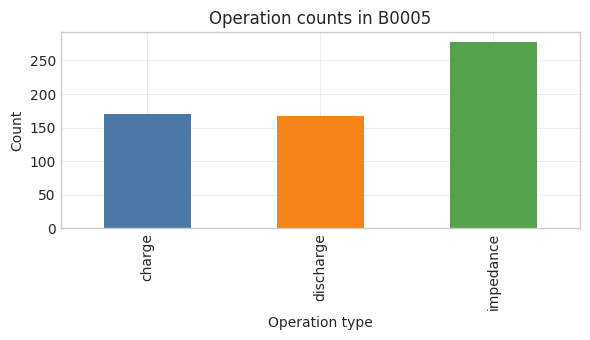

In [6]:
# Count operation types and visualize how the file is composed.
cycle_type_counts = pd.Series([cycle.type for cycle in cycles]).value_counts()
display(cycle_type_counts)

fig, ax = plt.subplots(figsize=(6, 3.5))
cycle_type_counts.sort_index().plot(kind="bar", ax=ax, color=["#4c78a8", "#f58518", "#54a24b"])
ax.set_title(f"Operation counts in {sample_path.stem}")
ax.set_xlabel("Operation type")
ax.set_ylabel("Count")
plt.tight_layout()


In [7]:
# Show which fields are available for charge, discharge, and impedance operations.
rows = []
for operation_type in sorted(set(cycle.type for cycle in cycles)):
    cycle = next(c for c in cycles if c.type == operation_type)
    rows.append({
        "operation_type": operation_type,
        "top_level_fields": public_mat_fields(cycle),
        "data_fields": public_mat_fields(cycle.data),
    })

pd.DataFrame(rows)


,operation_type,top_level_fields,data_fields
0,charge,"[type, ambient_temperature, time, data]","[Voltage_measured, Current_measured, Temperature_measured, Current_charge, Voltage_charge, Time]"
1,discharge,"[type, ambient_temperature, time, data]","[Voltage_measured, Current_measured, Temperature_measured, Current_load, Voltage_load, Time, Capacity]"
2,impedance,"[type, ambient_temperature, time, data]","[Sense_current, Battery_current, Current_ratio, Battery_impedance, Rectified_Impedance, Re, Rct]"


## Discharge Summary

The discharge summary converts each discharge operation into one row with capacity, duration, signal length, voltage statistics, current statistics, and temperature statistics. This table is still exploratory, but it already shows which variables are plausible candidates for later preprocessing.


In [8]:
# Small conversion helpers for MATLAB values that may be scalar or array-like.
def to_1d_array(value):
    return np.asarray(value).reshape(-1)

def optional_scalar(data, field_name):
    if not hasattr(data, field_name):
        return np.nan
    arr = np.asarray(getattr(data, field_name))
    if arr.size != 1:
        return np.nan
    return float(arr.reshape(-1)[0])

# Convert discharge operations into one compact row per discharge cycle.
def discharge_summary(cycles):
    records = []
    discharge_index = 0

    for raw_index, cycle in enumerate(cycles):
        if cycle.type != "discharge":
            continue

        data = cycle.data
        time = to_1d_array(data.Time)
        voltage = to_1d_array(data.Voltage_measured)
        current = to_1d_array(data.Current_measured)
        temperature = to_1d_array(data.Temperature_measured)

        records.append({
            "raw_cycle_index": raw_index,
            "discharge_cycle_index": discharge_index,
            "ambient_temperature": float(cycle.ambient_temperature),
            "capacity_ah": optional_scalar(data, "Capacity"),
            "duration_s": float(time[-1] - time[0]) if len(time) else np.nan,
            "n_samples": len(time),
            "voltage_min": float(np.nanmin(voltage)),
            "voltage_mean": float(np.nanmean(voltage)),
            "current_mean": float(np.nanmean(current)),
            "temperature_mean": float(np.nanmean(temperature)),
            "temperature_max": float(np.nanmax(temperature)),
        })
        discharge_index += 1

    return pd.DataFrame(records)

# Build the discharge-level table for the selected battery.
discharge_df = discharge_summary(cycles)
display(discharge_df.head())
display(discharge_df.describe().T)


,raw_cycle_index,discharge_cycle_index,ambient_temperature,capacity_ah,duration_s,n_samples,voltage_min,voltage_mean,current_mean,temperature_mean,temperature_max
0,1,0,24.0,1.856487,3690.234,197,2.612467,3.529829,-1.818702,32.572328,38.982181
1,3,1,24.0,1.846327,3672.344,196,2.587209,3.537320,-1.817560,32.725235,39.033398
2,5,2,24.0,1.835349,3651.641,195,2.651917,3.543737,-1.816487,32.642862,38.818797
3,7,3,24.0,1.835263,3631.563,194,2.592948,3.543666,-1.825589,32.514876,38.762305
4,9,4,24.0,1.834646,3629.172,194,2.547420,3.542343,-1.826114,32.382349,38.665393


,count,mean,std,min,25%,50%,75%,max
raw_cycle_index,168.0,293.000000,184.947314,1.000000,132.000000,291.000000,453.000000,613.000000
discharge_cycle_index,168.0,83.500000,48.641546,0.000000,41.750000,83.500000,125.250000,167.000000
ambient_temperature,168.0,24.000000,0.000000,24.000000,24.000000,24.000000,24.000000,24.000000
capacity_ah,168.0,1.572502,0.190413,1.287453,1.390021,1.557085,1.769163,1.856487
duration_s,168.0,3129.523887,246.654499,2792.485000,2901.343750,3086.078000,3323.230750,3690.234000
n_samples,168.0,299.315476,56.074922,179.000000,300.000000,314.500000,335.250000,371.000000
voltage_min,168.0,2.648939,0.049297,2.455679,2.636105,2.660192,2.682589,2.699983
voltage_mean,168.0,3.516787,0.032727,3.464021,3.486639,3.514629,3.551061,3.564103
current_mean,168.0,-1.807073,0.084677,-1.938881,-1.883128,-1.816639,-1.727548,-1.667447
temperature_mean,168.0,32.791319,0.713631,31.329996,32.282375,32.856923,33.356184,34.310885


**Interpretation.** For `B0005`, capacity ranges from about 1.856 Ah down to about 1.287 Ah. Discharge duration also decreases, while the number of samples varies between cycles. Ambient temperature is constant at 24 °C in the discharge rows.


## Capacity Fade

Capacity is the main degradation signal in this dataset. The NASA end-of-life criterion is approximately 30 percent capacity loss, from about 2.0 Ah to 1.4 Ah. For `B0005`, the first discharge cycle at or below 1.4 Ah appears at discharge cycle 124.


First discharge cycle at or below 1.4 Ah: 124


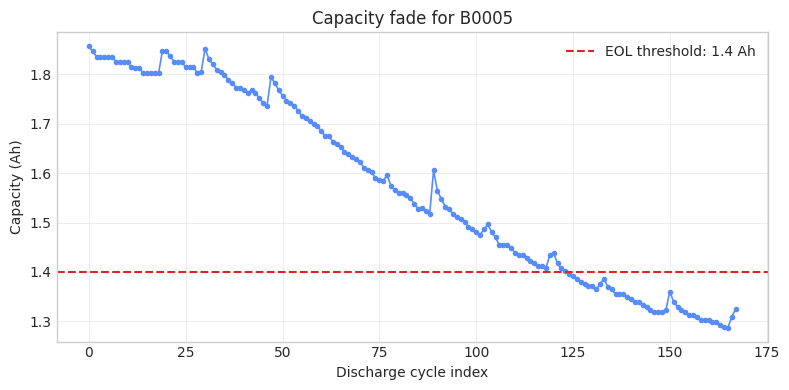

In [9]:
# Plot capacity fade and locate the first cycle crossing the NASA 1.4 Ah EOL threshold.
EOL_CAPACITY_AH = 1.4

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(discharge_df["discharge_cycle_index"], discharge_df["capacity_ah"], marker=".", linewidth=1.2)
ax.axhline(EOL_CAPACITY_AH, color="#d62728", linestyle="--", label="EOL threshold: 1.4 Ah")
ax.set_title(f"Capacity fade for {sample_path.stem}")
ax.set_xlabel("Discharge cycle index")
ax.set_ylabel("Capacity (Ah)")
ax.legend()
plt.tight_layout()

below_eol = discharge_df[discharge_df["capacity_ah"] <= EOL_CAPACITY_AH]
if below_eol.empty:
    print(f"{sample_path.stem} does not cross {EOL_CAPACITY_AH} Ah in this file.")
else:
    eol_cycle = int(below_eol.iloc[0]["discharge_cycle_index"])
    print(f"First discharge cycle at or below {EOL_CAPACITY_AH} Ah: {eol_cycle}")


**Interpretation.** `B0005` crosses the 1.4 Ah threshold at discharge cycle 124. This gives a concrete reference point for a future RUL target: for a discharge cycle `t`, one possible label is `124 - t`, clipped or filtered depending on how post-EOL cycles are handled.


## One Discharge Operation

A single discharge operation contains time-resolved voltage, current, and temperature measurements. These within-cycle signals explain what could later be summarized into features or resampled into fixed-length curves.


Capacity: 1.8565 Ah
Samples: 197
Duration: 3690.23 s


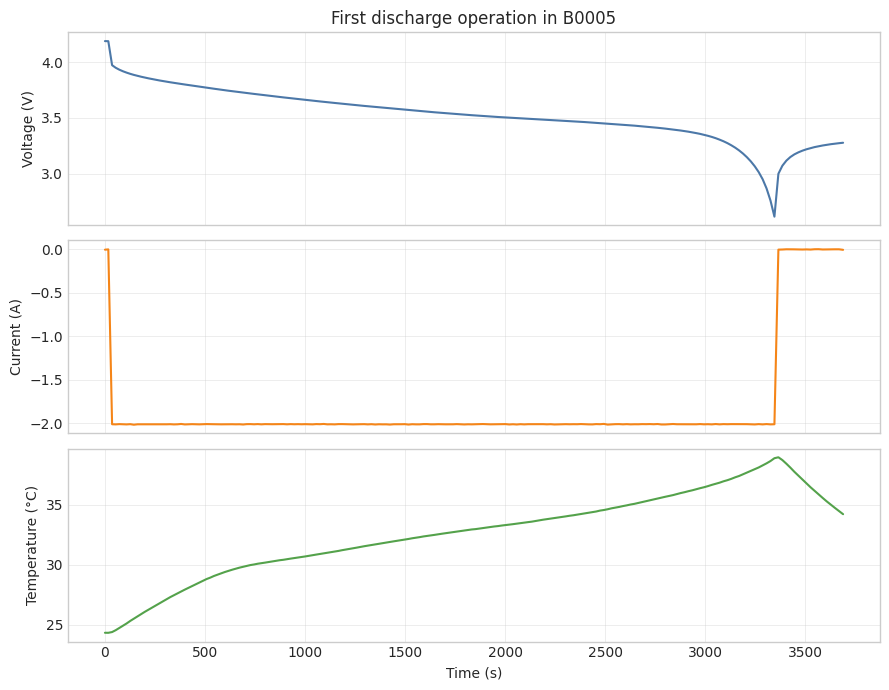

In [10]:
# Extract one discharge operation and plot its raw measured signals.
first_discharge = next(cycle for cycle in cycles if cycle.type == "discharge")
data = first_discharge.data

time = to_1d_array(data.Time)
voltage = to_1d_array(data.Voltage_measured)
current = to_1d_array(data.Current_measured)
temperature = to_1d_array(data.Temperature_measured)

print(f"Capacity: {float(np.asarray(data.Capacity).reshape(-1)[0]):.4f} Ah")
print(f"Samples: {len(time)}")
print(f"Duration: {time[-1] - time[0]:.2f} s")

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
axes[0].plot(time, voltage, color="#4c78a8")
axes[0].set_ylabel("Voltage (V)")
axes[0].set_title(f"First discharge operation in {sample_path.stem}")
axes[1].plot(time, current, color="#f58518")
axes[1].set_ylabel("Current (A)")
axes[2].plot(time, temperature, color="#54a24b")
axes[2].set_ylabel("Temperature (°C)")
axes[2].set_xlabel("Time (s)")
plt.tight_layout()


TODO viz n fct of RUL

**Interpretation.** The first discharge of `B0005` has capacity about 1.856 Ah, lasts about 3690 seconds, and contains 197 samples. This confirms that discharge curves are variable-length time series rather than fixed-size vectors.


## High-Level Inventory Across Batteries

The inventory summarizes all available battery files. It is useful for choosing training and test batteries later, because not every file has the same number of operations or the same degradation depth.


In [11]:
# Summarize every available battery file at a high level.
inventory_rows = []

for path in mat_files:
    battery_obj = load_battery_mat(path)
    battery_cycles = np.atleast_1d(battery_obj.cycle)
    type_counts = pd.Series([cycle.type for cycle in battery_cycles]).value_counts().to_dict()
    discharges = [cycle for cycle in battery_cycles if cycle.type == "discharge"]
    capacities = np.asarray([optional_scalar(cycle.data, "Capacity") for cycle in discharges], dtype=float)

    inventory_rows.append({
        "battery_id": path.stem,
        "folder": path.parent.name,
        "total_entries": len(battery_cycles),
        "charge_entries": type_counts.get("charge", 0),
        "discharge_entries": type_counts.get("discharge", 0),
        "impedance_entries": type_counts.get("impedance", 0),
        "first_capacity_ah": np.nan if capacities.size == 0 else capacities[0],
        "last_capacity_ah": np.nan if capacities.size == 0 else capacities[-1],
        "min_capacity_ah": np.nan if capacities.size == 0 else np.nanmin(capacities),
        "crosses_1_4ah": bool(np.any(capacities <= EOL_CAPACITY_AH)),
    })

inventory_df = pd.DataFrame(inventory_rows)
inventory_df.sort_values(["folder", "battery_id"]).reset_index(drop=True)


,battery_id,folder,total_entries,charge_entries,discharge_entries,impedance_entries,first_capacity_ah,last_capacity_ah,min_capacity_ah,crosses_1_4ah
0,B0005,1. BatteryAgingARC-FY08Q4,616,170,168,278,1.856487,1.325079,1.287453,True
1,B0006,1. BatteryAgingARC-FY08Q4,616,170,168,278,2.035338,1.185675,1.153818,True
2,B0007,1. BatteryAgingARC-FY08Q4,616,170,168,278,1.891052,1.432455,1.400455,False
3,B0018,1. BatteryAgingARC-FY08Q4,319,134,132,53,1.855005,1.341051,1.341051,True
4,B0025,2. BatteryAgingARC_25_26_27_28_P1,80,31,28,21,1.847011,1.767789,1.767789,False
5,B0026,2. BatteryAgingARC_25_26_27_28_P1,80,31,28,21,1.813250,1.768754,1.386337,True
6,B0027,2. BatteryAgingARC_25_26_27_28_P1,80,31,28,21,1.823308,1.770093,1.770093,False
7,B0028,2. BatteryAgingARC_25_26_27_28_P1,80,31,28,21,1.804685,1.717234,1.717234,False
8,B0025,3. BatteryAgingARC_25-44,80,31,28,21,1.847011,1.767789,1.767789,False
9,B0026,3. BatteryAgingARC_25-44,80,31,28,21,1.813250,1.768754,1.386337,True


**Interpretation.** The inventory shows heterogeneous file sizes and degradation coverage. Some batteries have long histories with many operation entries, while others are shorter. Later notebooks should decide which batteries are suitable for RUL modeling based on whether they reach or approach the 1.4 Ah threshold.


## Cross-Folder Battery Overview

The first detailed plots focused on `B0005`, but the dataset contains many more cells across different experimental folders. The following views keep folders visible so protocol differences are not hidden by a single combined plot.


In [12]:
# Build one combined discharge table across all battery files.
all_discharge_rows = []

for path in mat_files:
    battery_obj = load_battery_mat(path)
    df = discharge_summary(np.atleast_1d(battery_obj.cycle))
    df.insert(0, "battery_id", path.stem)
    df.insert(1, "folder", path.parent.name)
    all_discharge_rows.append(df)

all_discharge_df = pd.concat(all_discharge_rows, ignore_index=True)
all_discharge_df.head()


,battery_id,folder,raw_cycle_index,discharge_cycle_index,ambient_temperature,capacity_ah,duration_s,n_samples,voltage_min,voltage_mean,current_mean,temperature_mean,temperature_max
0,B0005,1. BatteryAgingARC-FY08Q4,1,0,24.0,1.856487,3690.234,197,2.612467,3.529829,-1.818702,32.572328,38.982181
1,B0005,1. BatteryAgingARC-FY08Q4,3,1,24.0,1.846327,3672.344,196,2.587209,3.537320,-1.817560,32.725235,39.033398
2,B0005,1. BatteryAgingARC-FY08Q4,5,2,24.0,1.835349,3651.641,195,2.651917,3.543737,-1.816487,32.642862,38.818797
3,B0005,1. BatteryAgingARC-FY08Q4,7,3,24.0,1.835263,3631.563,194,2.592948,3.543666,-1.825589,32.514876,38.762305
4,B0005,1. BatteryAgingARC-FY08Q4,9,4,24.0,1.834646,3629.172,194,2.547420,3.542343,-1.826114,32.382349,38.665393


### Capacity Fade for All Batteries, Grouped by Folder

Each subplot corresponds to one dataset folder. This makes it easier to see whether batteries within a subset behave similarly, while avoiding the false impression that all folders follow the same protocol.


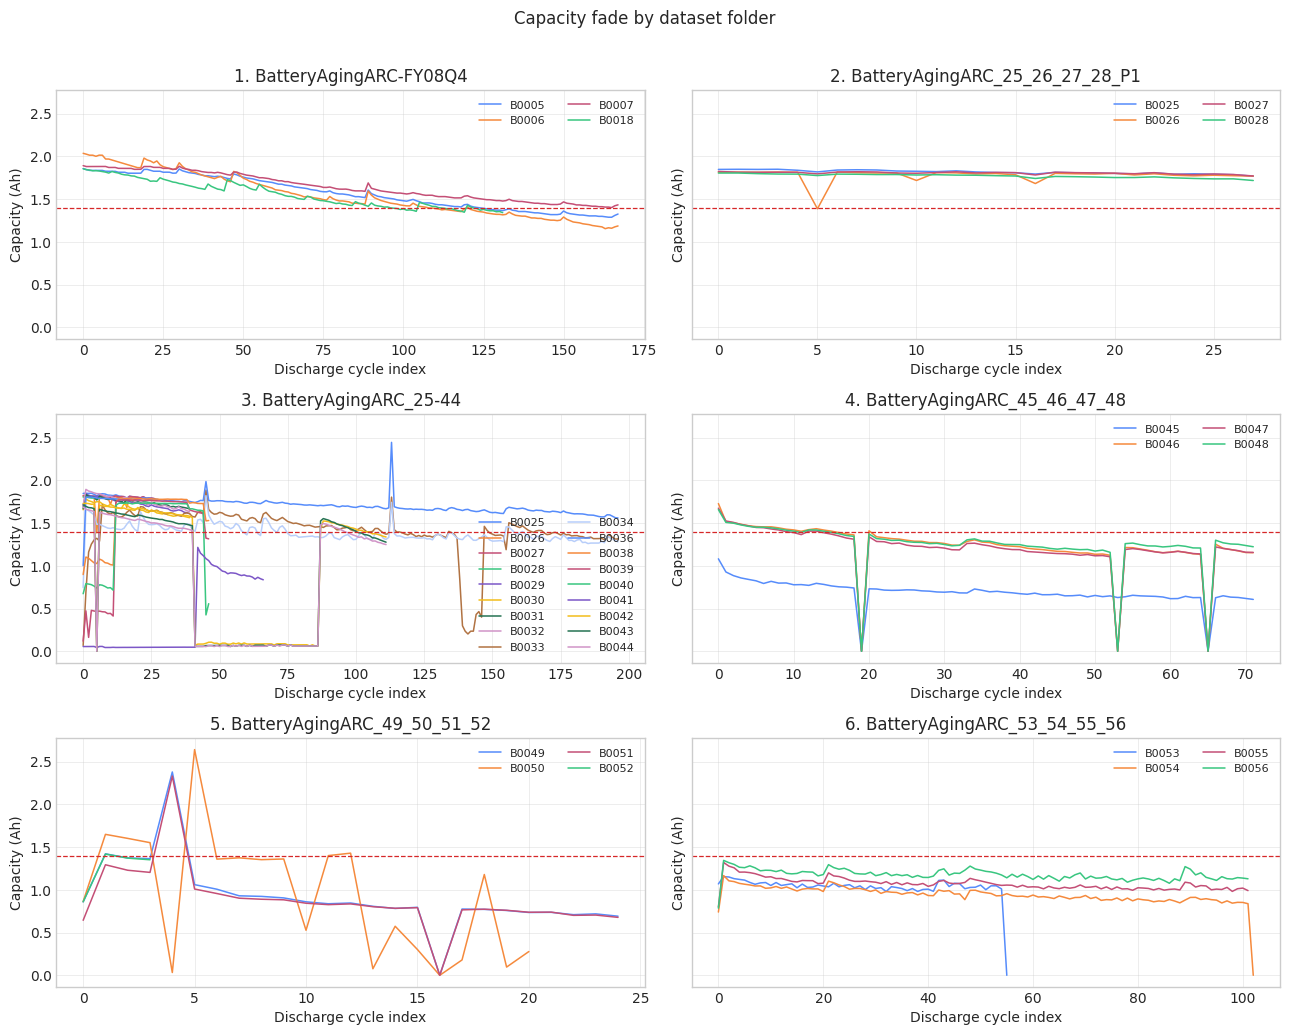

In [13]:
# Plot all battery capacity curves, keeping dataset folders visually separated.
folders = sorted(all_discharge_df["folder"].unique())
n_cols = 2
n_rows = int(np.ceil(len(folders) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 3.4 * n_rows), sharey=True)
axes = np.asarray(axes).reshape(-1)

for ax, folder in zip(axes, folders):
    folder_df = all_discharge_df[all_discharge_df["folder"] == folder]
    for battery_id, battery_df in folder_df.groupby("battery_id", sort=True):
        ax.plot(battery_df["discharge_cycle_index"], battery_df["capacity_ah"], linewidth=1.1, label=battery_id)
    ax.axhline(EOL_CAPACITY_AH, color="#d62728", linestyle="--", linewidth=0.9)
    ax.set_title(folder)
    ax.set_xlabel("Discharge cycle index")
    ax.set_ylabel("Capacity (Ah)")
    ax.legend(fontsize=8, ncol=2)

for ax in axes[len(folders):]:
    ax.set_axis_off()

fig.suptitle("Capacity fade by dataset folder", y=1.01)
plt.tight_layout()


### Folder-Level Summary

This table summarizes how many batteries and discharge cycles are available per folder, and whether the folder contains cells that cross the 1.4 Ah threshold.


In [14]:
# Aggregate discharge-cycle coverage and EOL crossing information by battery and folder.
battery_summary_df = (
    all_discharge_df.groupby(["folder", "battery_id"])
    .agg(
        discharge_cycles=("discharge_cycle_index", "count"),
        first_capacity_ah=("capacity_ah", "first"),
        last_capacity_ah=("capacity_ah", "last"),
        min_capacity_ah=("capacity_ah", "min"),
        max_ambient_temperature=("ambient_temperature", "max"),
        min_ambient_temperature=("ambient_temperature", "min"),
    )
    .reset_index()
)
battery_summary_df["crosses_1_4ah"] = battery_summary_df["min_capacity_ah"] <= EOL_CAPACITY_AH

folder_summary_df = (
    battery_summary_df.groupby("folder")
    .agg(
        batteries=("battery_id", "nunique"),
        total_discharge_cycles=("discharge_cycles", "sum"),
        median_discharge_cycles=("discharge_cycles", "median"),
        min_capacity_ah=("min_capacity_ah", "min"),
        batteries_crossing_1_4ah=("crosses_1_4ah", "sum"),
        min_ambient_temperature=("min_ambient_temperature", "min"),
        max_ambient_temperature=("max_ambient_temperature", "max"),
    )
    .reset_index()
)
folder_summary_df


,folder,batteries,total_discharge_cycles,median_discharge_cycles,min_capacity_ah,batteries_crossing_1_4ah,min_ambient_temperature,max_ambient_temperature
0,1. BatteryAgingARC-FY08Q4,4,636,168.0,1.153818,3,24.0,24.0
1,2. BatteryAgingARC_25_26_27_28_P1,4,112,28.0,1.386337,1,24.0,24.0
2,3. BatteryAgingARC_25-44,18,1407,47.0,0.000000,11,4.0,44.0
3,4. BatteryAgingARC_45_46_47_48,4,288,72.0,0.000000,4,4.0,4.0
4,5. BatteryAgingARC_49_50_51_52,4,100,25.0,0.000000,4,4.0,4.0
5,6. BatteryAgingARC_53_54_55_56,4,363,102.0,0.000000,4,4.0,4.0


### Candidate Batteries for RUL Modeling

A first conservative modeling subset should contain batteries with enough discharge cycles and a clear degradation trajectory. The table below flags batteries that cross the 1.4 Ah threshold and have at least 50 discharge cycles. This is not the final split, but it gives a transparent starting point.


In [15]:
# Flag a first conservative set of batteries for a 1.4 Ah RUL formulation.
candidate_batteries_df = battery_summary_df.copy()
candidate_batteries_df["candidate_for_1_4ah_rul"] = (
    candidate_batteries_df["crosses_1_4ah"]
    & (candidate_batteries_df["discharge_cycles"] >= 50)
)

candidate_batteries_df.sort_values(
    ["candidate_for_1_4ah_rul", "folder", "battery_id"],
    ascending=[False, True, True],
).reset_index(drop=True)


,folder,battery_id,discharge_cycles,first_capacity_ah,last_capacity_ah,min_capacity_ah,max_ambient_temperature,min_ambient_temperature,crosses_1_4ah,candidate_for_1_4ah_rul
0,1. BatteryAgingARC-FY08Q4,B0005,168,1.856487,1.325079,1.287453,24.0,24.0,True,True
1,1. BatteryAgingARC-FY08Q4,B0006,168,2.035338,1.185675,1.153818,24.0,24.0,True,True
2,1. BatteryAgingARC-FY08Q4,B0018,132,1.855005,1.341051,1.341051,24.0,24.0,True,True
3,3. BatteryAgingARC_25-44,B0033,197,0.068426,1.315283,0.068426,24.0,24.0,True,True
4,3. BatteryAgingARC_25-44,B0034,197,0.745930,1.280260,0.745930,24.0,24.0,True,True
5,3. BatteryAgingARC_25-44,B0036,197,1.001983,1.559113,1.001983,24.0,24.0,True,True
6,3. BatteryAgingARC_25-44,B0041,67,0.055620,0.836495,0.044092,4.0,4.0,True,True
7,3. BatteryAgingARC_25-44,B0042,112,1.728713,1.337469,0.000000,22.0,4.0,True,True
8,3. BatteryAgingARC_25-44,B0043,112,1.713783,1.276780,0.000000,22.0,4.0,True,True
9,3. BatteryAgingARC_25-44,B0044,112,1.686526,1.248625,0.000000,22.0,4.0,True,True


**Interpretation.** The cross-folder view confirms that the dataset is heterogeneous. Some folders are directly aligned with a 1.4 Ah EOL target, some stop around 1.6 Ah, and one group ended after a software crash. For later RUL experiments, it is better to define inclusion rules explicitly than to assume all battery files are equivalent.


## Comparative Aging and Signal Behavior

The next plots compare degradation behavior across selected batteries and inspect simple physical relationships in `B0005`: capacity fade, discharge duration, within-cycle voltage and temperature curves, impedance trends, and feature correlations.


In [16]:
# Select common starter batteries from the first subset for direct comparison.
preferred_battery_ids = ["B0005", "B0006", "B0007", "B0018"]
available_by_id = {path.stem: path for path in mat_files}
comparison_paths = [available_by_id[battery_id] for battery_id in preferred_battery_ids if battery_id in available_by_id]

if not comparison_paths:
    comparison_paths = mat_files[:4]

comparison_paths


[PosixPath('/home/aymen/data/nasa-battery/1. BatteryAgingARC-FY08Q4/B0005.mat'),
 PosixPath('/home/aymen/data/nasa-battery/1. BatteryAgingARC-FY08Q4/B0006.mat'),
 PosixPath('/home/aymen/data/nasa-battery/1. BatteryAgingARC-FY08Q4/B0007.mat'),
 PosixPath('/home/aymen/data/nasa-battery/1. BatteryAgingARC-FY08Q4/B0018.mat')]

### Multi-Battery Capacity Fade

Comparing several cells on the same axis shows that capacity fade is battery-dependent. Even cells from the same subset can degrade at different rates, which is important for later evaluation: train/test splits should be done by battery, not by randomly mixing cycles.


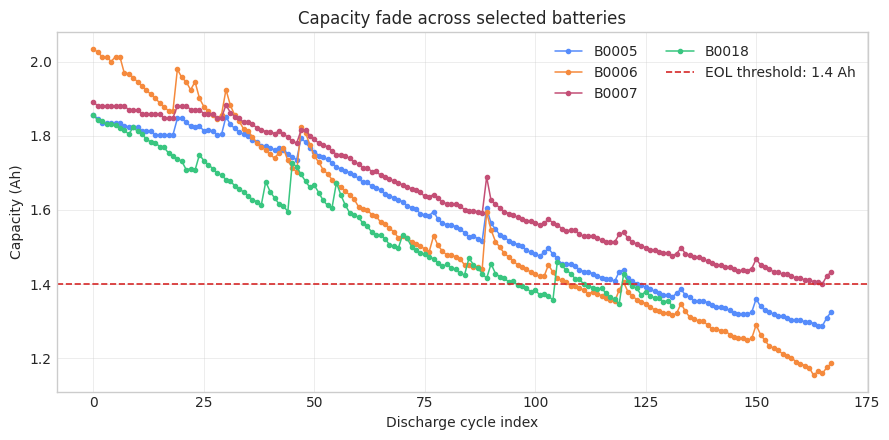

In [17]:
# Overlay capacity fade for selected batteries from the same experimental subset.
fig, ax = plt.subplots(figsize=(9, 4.5))

for path in comparison_paths:
    battery_obj = load_battery_mat(path)
    battery_cycles = np.atleast_1d(battery_obj.cycle)
    df = discharge_summary(battery_cycles)
    ax.plot(df["discharge_cycle_index"], df["capacity_ah"], marker=".", linewidth=1.1, label=path.stem)

ax.axhline(EOL_CAPACITY_AH, color="#d62728", linestyle="--", linewidth=1.2, label="EOL threshold: 1.4 Ah")
ax.set_title("Capacity fade across selected batteries")
ax.set_xlabel("Discharge cycle index")
ax.set_ylabel("Capacity (Ah)")
ax.legend(ncol=2)
plt.tight_layout()


**Interpretation.** The selected batteries do not follow identical degradation trajectories. This supports battery-wise evaluation: testing on unseen batteries is more realistic than randomly splitting individual discharge cycles from the same battery.


### Discharge Duration and Capacity Relationship

Discharge duration is a physically intuitive proxy for usable capacity. In `B0005`, both capacity and discharge duration decrease over aging, and the scatter plot shows that duration carries information about battery health.


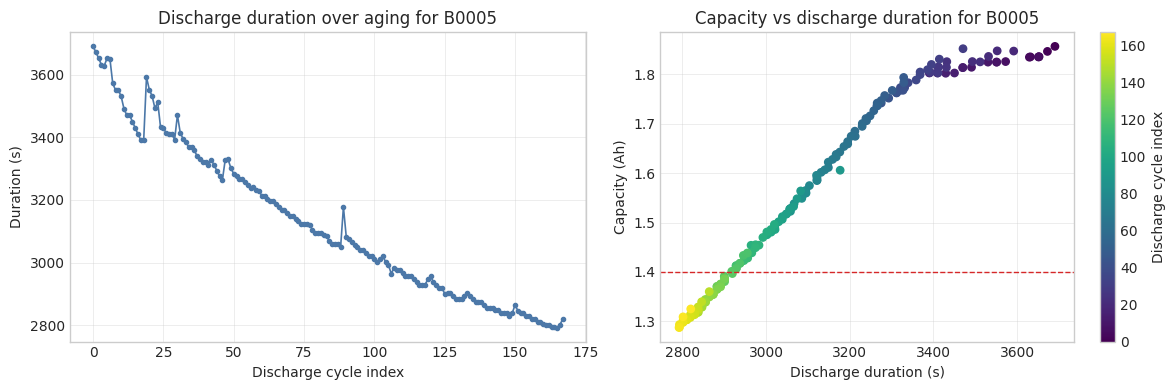

In [18]:
# Compare discharge duration over aging and its direct relationship with capacity.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(discharge_df["discharge_cycle_index"], discharge_df["duration_s"], marker=".", linewidth=1.2, color="#4c78a8")
axes[0].set_title(f"Discharge duration over aging for {sample_path.stem}")
axes[0].set_xlabel("Discharge cycle index")
axes[0].set_ylabel("Duration (s)")

scatter = axes[1].scatter(
    discharge_df["duration_s"],
    discharge_df["capacity_ah"],
    c=discharge_df["discharge_cycle_index"],
    cmap="viridis",
    s=28,
)
axes[1].axhline(EOL_CAPACITY_AH, color="#d62728", linestyle="--", linewidth=1.0)
axes[1].set_title(f"Capacity vs discharge duration for {sample_path.stem}")
axes[1].set_xlabel("Discharge duration (s)")
axes[1].set_ylabel("Capacity (Ah)")
fig.colorbar(scatter, ax=axes[1], label="Discharge cycle index")
plt.tight_layout()


**Interpretation.** The duration-capacity relationship is one of the clearest simple signals in the inspection analysis. It provides a useful sanity check for later models: a baseline should be able to exploit the fact that shorter discharges generally correspond to lower capacity.


### Early, Middle, and Late Discharge Curves

Overlaying early, middle, and late discharge curves shows how aging changes the shape of the measured signals. The voltage profile shortens as capacity decreases, while the temperature profile gives a first view of whether thermal behavior changes across lifetime.


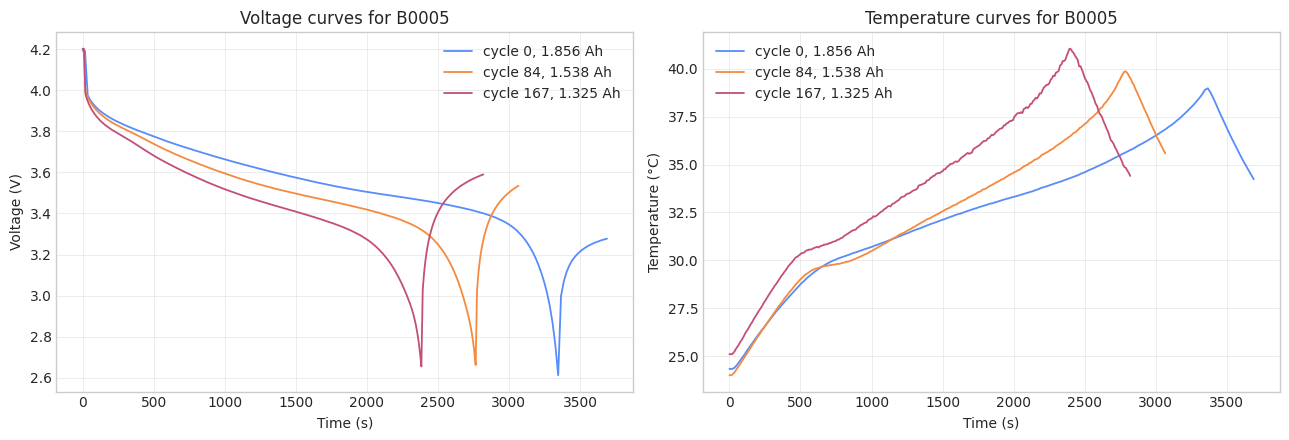

In [19]:
# Pick early, middle, and late discharge cycles and compare their raw curves.
def selected_discharge_cycles(cycles):
    discharges = [cycle for cycle in cycles if cycle.type == "discharge"]
    if not discharges:
        return []
    indices = sorted(set([0, len(discharges) // 2, len(discharges) - 1]))
    return [(index, discharges[index]) for index in indices]

selected = selected_discharge_cycles(cycles)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for discharge_index, cycle in selected:
    data = cycle.data
    time = to_1d_array(data.Time)
    capacity = optional_scalar(data, "Capacity")
    label = f"cycle {discharge_index}, {capacity:.3f} Ah"
    axes[0].plot(time, to_1d_array(data.Voltage_measured), linewidth=1.3, label=label)
    axes[1].plot(time, to_1d_array(data.Temperature_measured), linewidth=1.3, label=label)

axes[0].set_title(f"Voltage curves for {sample_path.stem}")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Voltage (V)")
axes[1].set_title(f"Temperature curves for {sample_path.stem}")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Temperature (°C)")
for ax in axes:
    ax.legend()
plt.tight_layout()


**Interpretation.** The later-life discharge curve is shorter, matching the observed capacity loss. These overlays also motivate two possible preprocessing paths: extract compact cycle-level features, or resample full curves to a common length for sequence models.


### Impedance Trends: Re and Rct

The impedance operations provide resistance-related indicators. `Re` and `Rct` are not measured at every discharge cycle, so they require alignment before modeling, but their evolution is useful for understanding electrochemical aging.


,raw_cycle_index,impedance_index,ambient_temperature,Re,Rct
0,40,0,24.0,0.044669,0.069456
1,42,1,24.0,0.046687,0.076275
2,44,2,24.0,0.044843,0.067972
3,46,3,24.0,0.046195,0.074534
4,48,4,24.0,0.045101,0.068528


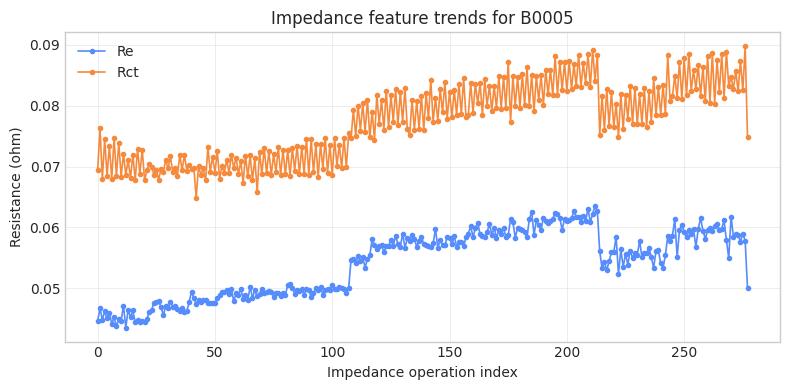

In [20]:
# Extract impedance operations into a compact table with Re and Rct.
def impedance_summary(cycles):
    rows = []
    impedance_index = 0

    for raw_index, cycle in enumerate(cycles):
        if cycle.type != "impedance":
            continue

        rows.append({
            "raw_cycle_index": raw_index,
            "impedance_index": impedance_index,
            "ambient_temperature": float(cycle.ambient_temperature),
            "Re": optional_scalar(cycle.data, "Re"),
            "Rct": optional_scalar(cycle.data, "Rct"),
        })
        impedance_index += 1

    return pd.DataFrame(rows)

# Plot resistance-related impedance features over impedance operation index.
impedance_df = impedance_summary(cycles)
display(impedance_df.head())

if impedance_df.empty:
    print(f"No impedance operations found for {sample_path.stem}.")
else:
    fig, ax = plt.subplots(figsize=(8, 4))
    for column in ["Re", "Rct"]:
        if impedance_df[column].notna().any():
            ax.plot(impedance_df["impedance_index"], impedance_df[column], marker=".", linewidth=1.2, label=column)
    ax.set_title(f"Impedance feature trends for {sample_path.stem}")
    ax.set_xlabel("Impedance operation index")
    ax.set_ylabel("Resistance (ohm)")
    ax.legend()
    plt.tight_layout()


**Interpretation.** The impedance features fluctuate but remain physically relevant because resistance-related quantities are expected to change with aging. Since impedance measurements are more frequent than discharge cycles in this file, they should be treated carefully when merged with discharge-based RUL targets.


### Capacity Fade Colored by Ambient Temperature

Coloring capacity by ambient temperature checks whether capacity changes are mixed with changing test conditions. For `B0005`, ambient temperature is constant at 24 °C in the discharge summary, so this plot mainly confirms that temperature is not a confounding variable for this specific file.


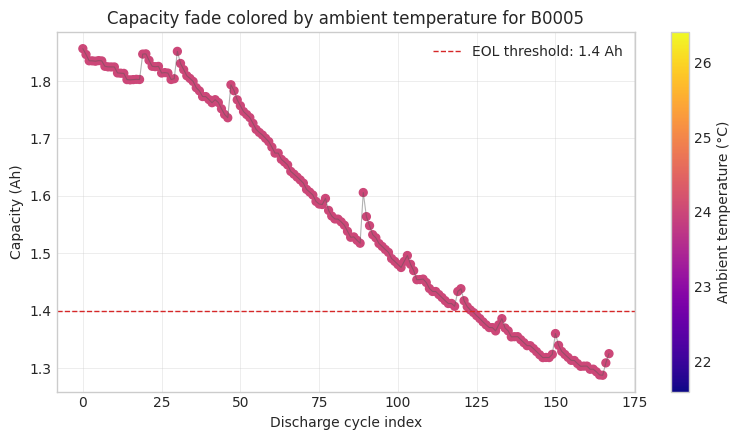

In [21]:
# Color the capacity fade curve by ambient temperature to check for changing test conditions.
fig, ax = plt.subplots(figsize=(8, 4.5))
scatter = ax.scatter(
    discharge_df["discharge_cycle_index"],
    discharge_df["capacity_ah"],
    c=discharge_df["ambient_temperature"],
    cmap="plasma",
    s=32,
)
ax.plot(discharge_df["discharge_cycle_index"], discharge_df["capacity_ah"], color="#555555", linewidth=0.8, alpha=0.45)
ax.axhline(EOL_CAPACITY_AH, color="#d62728", linestyle="--", linewidth=1.0, label="EOL threshold: 1.4 Ah")
ax.set_title(f"Capacity fade colored by ambient temperature for {sample_path.stem}")
ax.set_xlabel("Discharge cycle index")
ax.set_ylabel("Capacity (Ah)")
fig.colorbar(scatter, ax=ax, label="Ambient temperature (°C)")
ax.legend()
plt.tight_layout()


**Interpretation.** Because all discharge rows for `B0005` have ambient temperature equal to 24 °C, the color scale does not reveal separate temperature regimes. This is still useful: it means capacity fade in this cell is not visually explained by changing ambient test temperature.


### Correlation Heatmap for Discharge Summary Features

The heatmap summarizes linear relationships among the discharge-level features. It helps identify redundant variables and early feature candidates before building the cleaned discharge-cycle dataset.


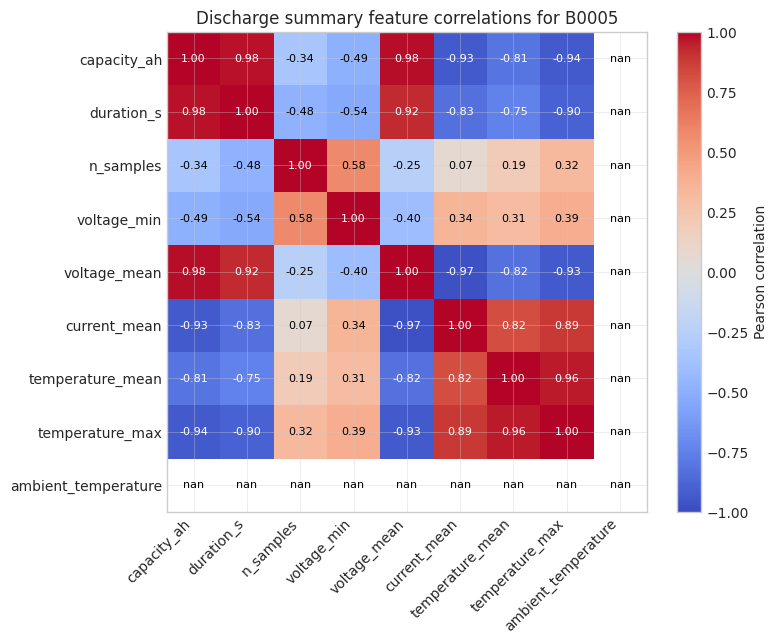

In [22]:
# Compute and annotate correlations between discharge-level summary features.
corr_columns = [
    "capacity_ah",
    "duration_s",
    "n_samples",
    "voltage_min",
    "voltage_mean",
    "current_mean",
    "temperature_mean",
    "temperature_max",
    "ambient_temperature",
]
available_corr_columns = [column for column in corr_columns if column in discharge_df.columns]
corr = discharge_df[available_corr_columns].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)

for row_index in range(len(corr.index)):
    for column_index in range(len(corr.columns)):
        value = corr.iloc[row_index, column_index]
        text_color = "white" if abs(value) > 0.65 else "black"
        ax.text(column_index, row_index, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=8)

ax.set_title(f"Discharge summary feature correlations for {sample_path.stem}")
fig.colorbar(im, ax=ax, label="Pearson correlation")
plt.tight_layout()


**Interpretation.** The correlation matrix should be read as an exploratory guide, not proof of causality. Strong relationships involving capacity, duration, and voltage or temperature summaries indicate which variables may be useful for baseline models and which may be redundant.


### Number of Samples per Discharge Cycle

The number of measurements per discharge cycle is not constant. This matters because raw within-cycle curves cannot be stacked directly into a fixed-size model input without padding, truncation, or resampling.


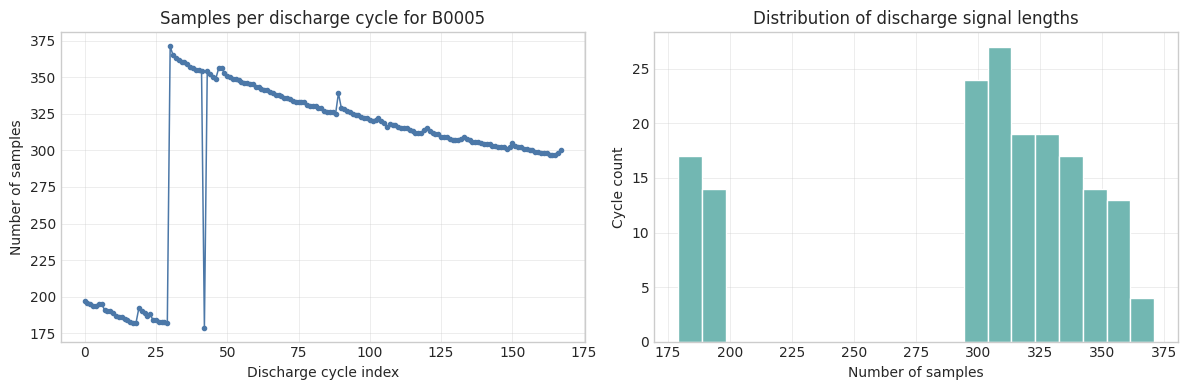

In [23]:
# Inspect variable sequence lengths before deciding on padding or resampling.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(discharge_df["discharge_cycle_index"], discharge_df["n_samples"], marker=".", linewidth=1.1, color="#4c78a8")
axes[0].set_title(f"Samples per discharge cycle for {sample_path.stem}")
axes[0].set_xlabel("Discharge cycle index")
axes[0].set_ylabel("Number of samples")

axes[1].hist(discharge_df["n_samples"], bins=20, color="#72b7b2", edgecolor="white")
axes[1].set_title("Distribution of discharge signal lengths")
axes[1].set_xlabel("Number of samples")
axes[1].set_ylabel("Cycle count")

plt.tight_layout()


**Interpretation.** Signal lengths vary substantially across discharge cycles. For `B0005`, the summary statistics show discharge cycles ranging from 179 to 371 samples. This supports using resampling or cycle-level summary features in the next preprocessing step.


### Capacity vs Nearby Impedance Features

This plot aligns each impedance operation to the nearest discharge operation by raw cycle index, then compares `Re` and `Rct` against the nearest discharge capacity. This is a simple inspection rule, not a final modeling decision, but it shows whether impedance features have a visible relationship with degradation.


,impedance_index,impedance_raw_cycle_index,nearest_discharge_cycle_index,nearest_discharge_raw_cycle_index,raw_cycle_distance,capacity_ah,Re,Rct
0,0.0,40.0,19.0,41.0,1.0,1.847026,0.044669,0.069456
1,1.0,42.0,19.0,41.0,1.0,1.847026,0.046687,0.076275
2,2.0,44.0,20.0,45.0,1.0,1.847417,0.044843,0.067972
3,3.0,46.0,20.0,45.0,1.0,1.847417,0.046195,0.074534
4,4.0,48.0,21.0,49.0,1.0,1.836177,0.045101,0.068528


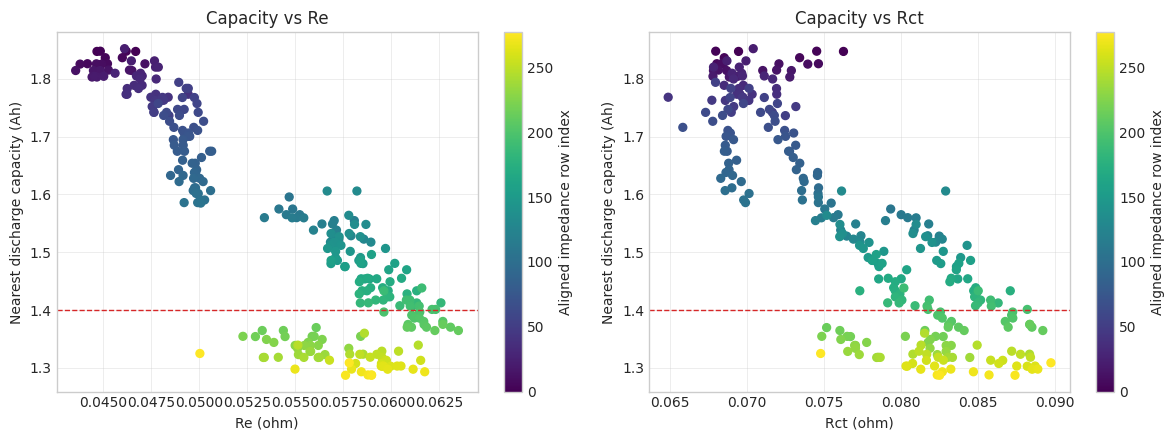

In [24]:
# Align impedance measurements to the nearest discharge operation for exploratory comparison.
if "impedance_df" not in globals():
    impedance_df = impedance_summary(cycles)

if impedance_df.empty:
    print(f"No impedance operations found for {sample_path.stem}.")
else:
    aligned_rows = []

    for _, imp_row in impedance_df.iterrows():
        distances = (discharge_df["raw_cycle_index"] - imp_row["raw_cycle_index"]).abs()
        nearest_discharge = discharge_df.loc[distances.idxmin()]
        aligned_rows.append({
            "impedance_index": imp_row["impedance_index"],
            "impedance_raw_cycle_index": imp_row["raw_cycle_index"],
            "nearest_discharge_cycle_index": nearest_discharge["discharge_cycle_index"],
            "nearest_discharge_raw_cycle_index": nearest_discharge["raw_cycle_index"],
            "raw_cycle_distance": abs(nearest_discharge["raw_cycle_index"] - imp_row["raw_cycle_index"]),
            "capacity_ah": nearest_discharge["capacity_ah"],
            "Re": imp_row["Re"],
            "Rct": imp_row["Rct"],
        })

    impedance_capacity_df = pd.DataFrame(aligned_rows)
    display(impedance_capacity_df.head())

    # Compare nearest discharge capacity against the two impedance features.
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for ax, column in zip(axes, ["Re", "Rct"]):
        valid = impedance_capacity_df[[column, "capacity_ah"]].dropna()
        if valid.empty:
            ax.text(0.5, 0.5, f"No valid {column} values", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue
        scatter = ax.scatter(
            valid[column],
            valid["capacity_ah"],
            c=valid.index,
            cmap="viridis",
            s=32,
        )
        ax.axhline(EOL_CAPACITY_AH, color="#d62728", linestyle="--", linewidth=1.0)
        ax.set_title(f"Capacity vs {column}")
        ax.set_xlabel(f"{column} (ohm)")
        ax.set_ylabel("Nearest discharge capacity (Ah)")
        fig.colorbar(scatter, ax=ax, label="Aligned impedance row index")

    plt.tight_layout()


**Interpretation.** The aligned preview shows impedance operations are usually very close to a discharge operation in raw cycle index for `B0005` (distance 1 in the first rows). That makes nearest-neighbor alignment reasonable for inspection. Before using impedance in a model, the alignment rule should be made explicit and applied consistently across all batteries.
